In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

df = pd.read_csv("../data/monthly.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['Date'] >= '1971-01-01'].copy().reset_index(drop=True)

print(f"TensorFlow version: {tf.__version__}")
print(f"Shape: {df.shape}")

TensorFlow version: 2.20.0
Shape: (662, 2)


In [2]:
test_size = 24
sequence_length = 12  # use 12 months of history to predict next month

# Scale price to 0-1 range
scaler = MinMaxScaler()
scaled_price = scaler.fit_transform(df[['Price']])

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_price, sequence_length)

# Split
X_train = X[:-test_size]
y_train = y[:-test_size]
X_test = X[-test_size:]
y_test = y[-test_size:]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (626, 12, 1)
X_test shape: (24, 12, 1)


In [3]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(sequence_length, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

c:\Users\evely\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0036 - val_loss: 0.0022
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.1198e-04 - val_loss: 6.4071e-04
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.5044e-04 - val_loss: 0.0011
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.6944e-04 - val_loss: 0.0010
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.1004e-04 - val_loss: 5.5828e-04
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.4148e-04 - val_loss: 0.0014
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.7726e-04 - val_loss: 4.6186e-04
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3303e-04 - val_loss: 4.5414e-04
Epoch 9/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.0141e-04 - val_loss: 0.0010
Epoch 10/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.0803e-04 - val_loss: 5.2612e-04
Epoch 11/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.7520e-04 - val_loss: 8.1711e-04
Epoch 12/

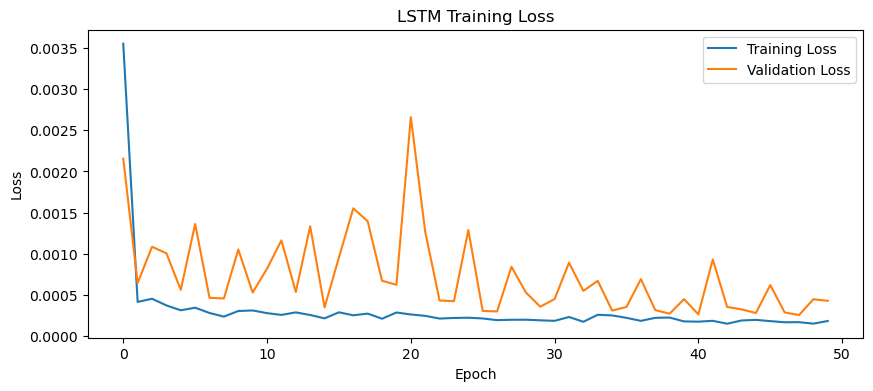

In [4]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [5]:
# Predict
lstm_pred_scaled = model.predict(X_test)

# Reverse the scaling to get real dollar values
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

mae_lstm = mean_absolute_error(y_test_actual, lstm_pred)
print(f"LSTM MAE: {mae_lstm:.2f}")
print(f"ARIMA MAE:          1096.23")
print(f"Naive baseline MAE: 1129.51")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
LSTM MAE: 387.57
ARIMA MAE:          1096.23
Naive baseline MAE: 1129.51


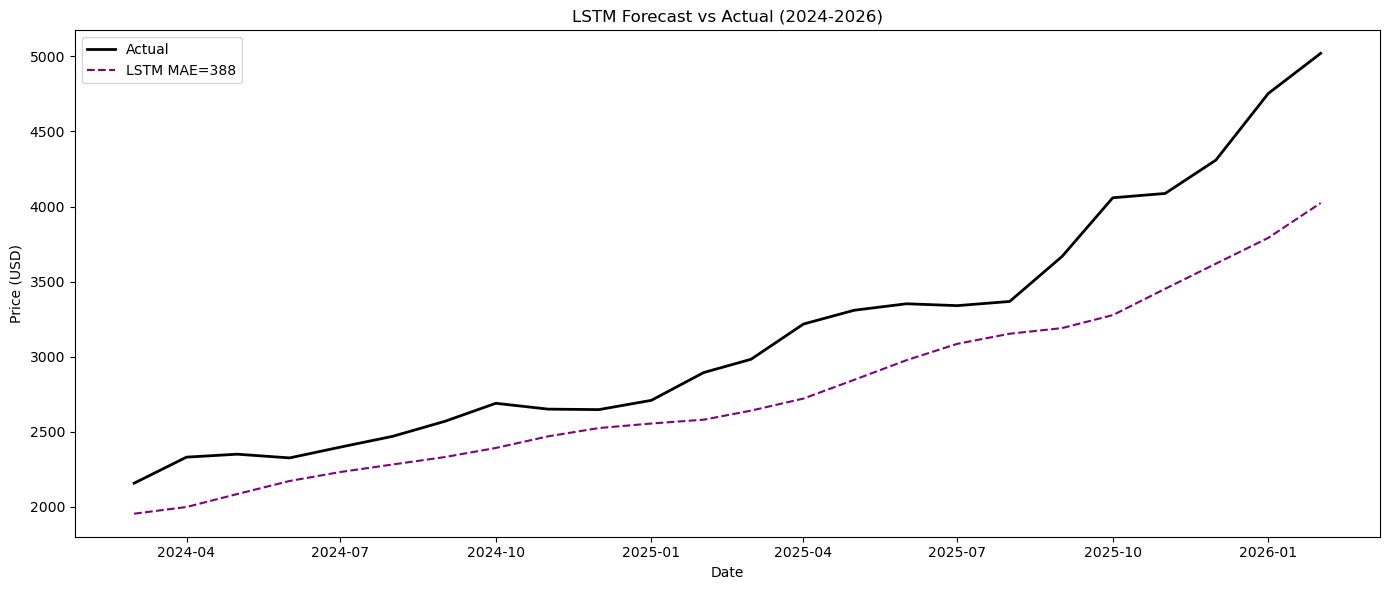

In [6]:
test_dates = df['Date'].iloc[-test_size:].values

plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_actual, label='Actual', color='black', linewidth=2)
plt.plot(test_dates, lstm_pred, label=f'LSTM MAE={mae_lstm:.0f}', linestyle='--', color='purple')
plt.title('LSTM Forecast vs Actual (2024-2026)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
import os
os.makedirs('../models', exist_ok=True)
model.save('../models/lstm_model.keras')
print("LSTM model saved.")

LSTM model saved.
